In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lc_reconstruction_analysis.utils as utils
import lc_reconstruction_analysis.clustering as clustering
import lc_reconstruction_analysis.visualization as visualization
%matplotlib inline

# Load Data

In [2]:
# Define path to data
DATA_DIR = Path("/data/")
# Load data frame of cells, and networkx graphs
dataDF, graphs = utils.load_cells(DATA_DIR)
df = clustering.build_length_df(dataDF, graphs, DATA_DIR)

Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N064-68221-JN.json
Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N025-685221-PG.json
Missing structure axon for /data/685221_12_5_24/Complete_annotated/N064-685221-JN.json
Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json
Missing structure dendrite for /data/648434_12_5_24/Complete_annotated/N024-648434-SS.json
Error finding structures for: N025-685221-PG, dropping from dataframe
Error finding structures for: N064-68221-JN, dropping from dataframe
Error finding structures for: N064-685221-JN, dropping from dataframe
Error finding structures for: N051-685221 -YP, dropping from dataframe
Error finding structures for: N024-648434-SS, dropping from dataframe


# Plot soma location colored by axon % in each brain region

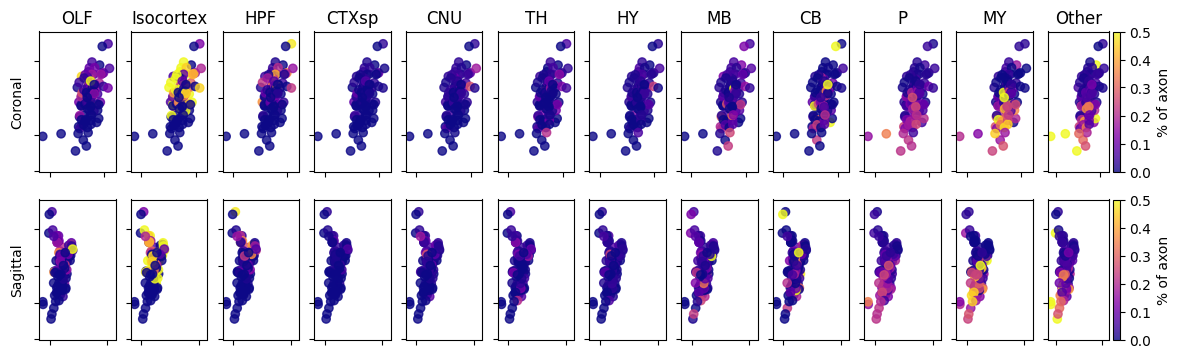

In [3]:
visualization.plot_all_soma_location(dataDF, df)

Same plot, but now each brain region has independent color axes

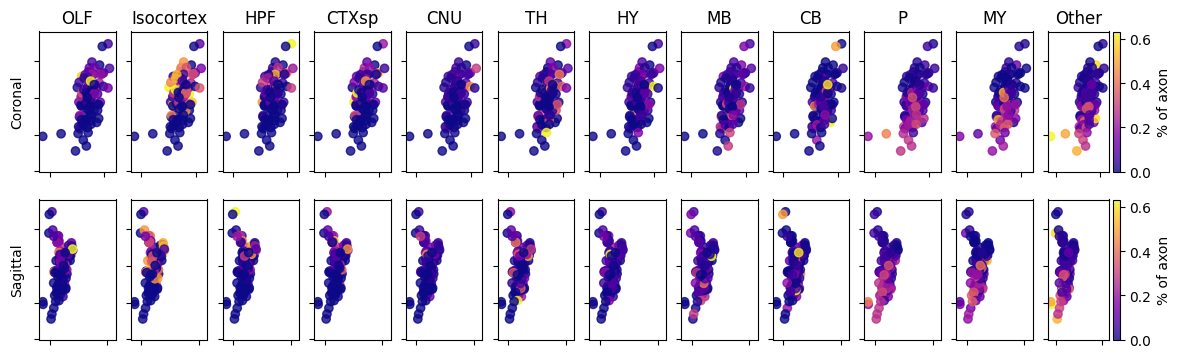

In [4]:
visualization.plot_all_soma_location(dataDF, df,vmax=None)

# Plot soma location colored by axon length in each brain region

In [5]:
df_unnormalized = clustering.build_length_df(dataDF, graphs, DATA_DIR, normalize_df=False)

Plotted with a consistent color axis

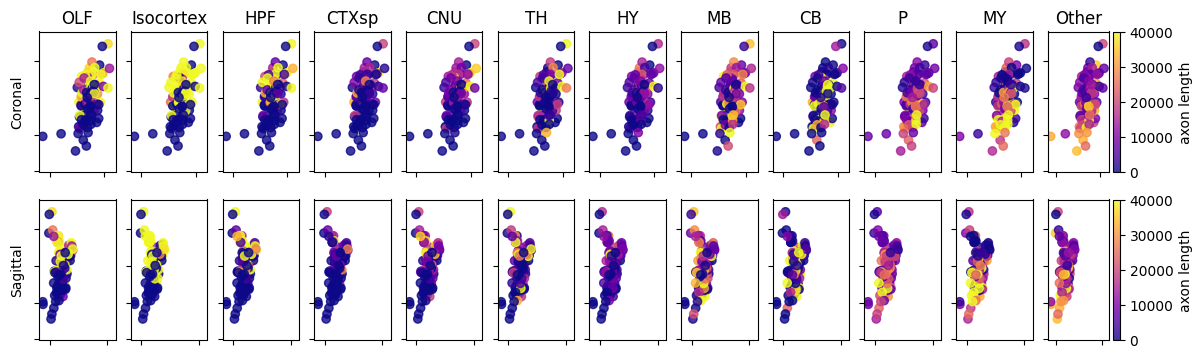

In [6]:
visualization.plot_all_soma_location(dataDF, df_unnormalized, ylabel='axon length',vmax=40000)

Plotted with independent color axes for each brain region

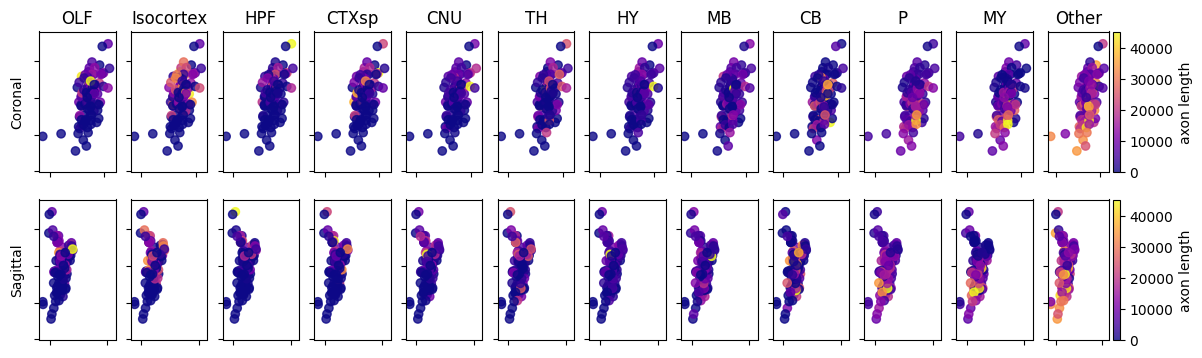

In [7]:
visualization.plot_all_soma_location(dataDF, df_unnormalized, ylabel='axon length',vmax=None)

# Plot total axon length

In [8]:
df_unnormalized['total axon length'] = df_unnormalized.sum(axis=1)

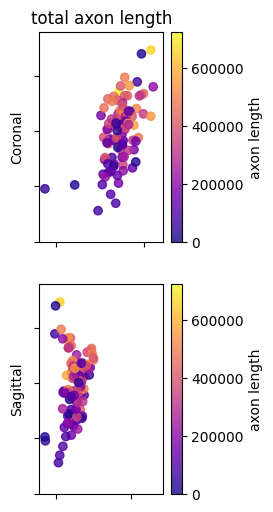

In [9]:
fig, ax = plt.subplots(2,1,figsize=(2,6))
visualization.plot_soma_location(
    dataDF, 
    df_unnormalized, 
    color_by='total axon length', 
    vmax=None,
    ax=ax,
    add_rows=True,
    ylabel='axon length'
)

# Plot branches

In [10]:
graph_branches = []
for graph in df_unnormalized.index.values:
    degrees = [graphs[graph].out_degree(x) for x in graphs[graph].nodes]
    branches = [x-1 if x > 1 else 0 for x in degrees]
    graph_branches.append(np.sum(branches))
df_unnormalized['branches'] = graph_branches

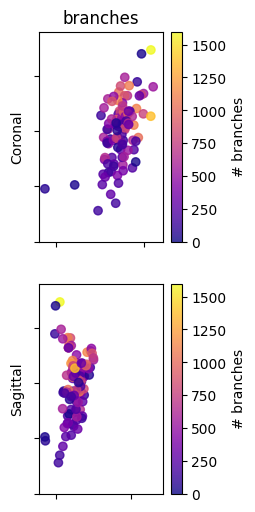

In [11]:
fig, ax = plt.subplots(2,1,figsize=(2,6))
visualization.plot_soma_location(
    dataDF, 
    df_unnormalized, 
    color_by='branches', 
    vmax=None,
    ax=ax,
    add_rows=True, 
    ylabel='# branches'
)

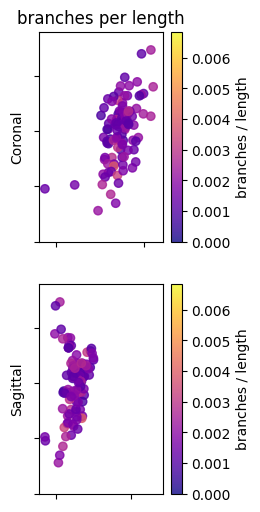

In [12]:
df_unnormalized['branches per length'] = df_unnormalized['branches'] / df_unnormalized['total axon length']
fig, ax = plt.subplots(2,1,figsize=(2,6))
visualization.plot_soma_location(
    dataDF, 
    df_unnormalized, 
    color_by='branches per length', 
    vmax=None,
    ax=ax,
    add_rows=True,
    ylabel='branches / length'
)

# Summary

Axon projections to different brain structures shows a clear dependence on soma location. The relationship between soma location and axon projection targets does not aappear to be strictly binary